In [1]:
#Imports

import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import AdamW
from CNO2D_def import CNO2D
import matplotlib.pyplot as plt
import h5py
import time

torch.manual_seed(0)
np.random.seed(0)

In [2]:
path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N128_multi.h5"

with h5py.File(path, "r") as f:
    omega = f["omega"][:]


i_data = torch.tensor(omega[:, 0, :, :], dtype=torch.float32)[:, None, :]
f_data = torch.tensor(omega[:, 1, :, :], dtype=torch.float32)[:, None, :]

In [6]:
train_ratio = 0.8
val_patience = 25

# Load the data
s = i_data.shape[-1]
num_samples = i_data.shape[0]
n_train = int(num_samples * train_ratio)

i_data = F.interpolate(i_data, size = s, mode = "bicubic", align_corners= False)
f_data = F.interpolate(f_data, size = s, mode = "bicubic", align_corners= False)

input_function_train = i_data[:n_train, :]
output_function_train = f_data[:n_train, :]
input_function_test = i_data[n_train:, :]
output_function_test = f_data[n_train:, :]

batch_size = 10

train_loader = DataLoader(TensorDataset(input_function_train, output_function_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(input_function_test, output_function_test), batch_size=batch_size, shuffle=False)


#---------------------
# Define the hyperparameters and the model:
#---------------------

learning_rate = 5e-4
epochs = 500
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
time_loss = np.zeros((2,epochs))


N_layers = 4
N_res    = 4
N_res_neck = 4
channel_multiplier = 16

In [7]:
#-----------
# TRAIN:
#-----------

model = CNO2D(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = s,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = True)

time_loss = np.zeros((2,epochs))

model.to(device)
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-8)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
step_size = 15
gamma = 0.5
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

criterion = torch.nn.MSELoss()
use_patience = True
freq_print = 1
epochs_no_improve = 0
best_val_loss = 1e12
start_time = time.time()
for epoch in range(epochs):
    model.train()
    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(train_loader):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)

        optimizer.zero_grad()
        output_pred_batch = model(input_batch)
        loss_f = criterion(output_pred_batch, output_batch)
        loss_f.backward()

        #clip
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        if not torch.isfinite(grad_norm):
            print(f"bad grad @ epoch {epoch}, step {step}, grad_norm {grad_norm}")
            optimizer.zero_grad(set_to_none = True)
            continue

        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(train_loader)

    scheduler.step()

    #Validation
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        for step, (input_batch, output_batch) in enumerate(val_loader):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)

            output_pred_batch = model(input_batch)
            
            if not torch.isfinite(output_pred_batch).all():
                print(f"[BAD PRED] epoch {epoch} step {step}")
                print("pred min/max:", output_pred_batch.min().item(), output_pred_batch.max().item())
                raise RuntimeError("Non-finite prediction")

            loss_f = criterion(output_pred_batch, output_batch)
            if not torch.isfinite(loss_f):
                print(f"[BAD LOSS] epoch {epoch} step {step}")
                raise RuntimeError("Non-finite loss")
            
            val_loss += F.mse_loss(output_pred_batch, output_batch).item()
        val_loss /= len(val_loader)

    if epoch % freq_print == 0: print(f"Epoch {epoch:03d} | Train {train_mse:.4e} | Val {val_loss:.4e}")

    # Early stopping
    if use_patience:
        if val_loss < best_val_loss * (1 - 1e-3):
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0

        else:
            if best_val_loss * (1 - 1e-3) < val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve += 1
            if epochs_no_improve >= val_patience:
                print("Early stop triggered.")
                break

    time_loss[0][epoch] = time.time() - start_time
    time_loss[1][epoch] = val_loss

time_loss = time_loss[:, :epoch]
model.load_state_dict(best_state)

print("Training complete. Best val loss:", best_val_loss)

Epoch 000 | Train 5.8748e-02 | Val 2.2352e-02
Epoch 001 | Train 1.4864e-02 | Val 1.4860e-02
Epoch 002 | Train 1.0144e-02 | Val 8.6412e-03
Epoch 003 | Train 7.3876e-03 | Val 7.6225e-03
Epoch 004 | Train 6.1701e-03 | Val 6.5377e-03
Epoch 005 | Train 5.7057e-03 | Val 7.4368e-03
Epoch 006 | Train 4.9726e-03 | Val 5.6581e-03
Epoch 007 | Train 4.4268e-03 | Val 1.1109e-02
Epoch 008 | Train 4.4584e-03 | Val 4.0289e-03
Epoch 009 | Train 3.6540e-03 | Val 4.7852e-03
Epoch 010 | Train 3.4301e-03 | Val 3.7620e-03
Epoch 011 | Train 3.8305e-03 | Val 3.1039e-03
Epoch 012 | Train 3.2916e-03 | Val 3.2917e-03
Epoch 013 | Train 3.0223e-03 | Val 2.8624e-03
Epoch 014 | Train 2.7994e-03 | Val 2.8217e-03
Epoch 015 | Train 2.4965e-03 | Val 3.1047e-03
Epoch 016 | Train 2.4855e-03 | Val 2.6047e-03
Epoch 017 | Train 2.2200e-03 | Val 3.2158e-03
Epoch 018 | Train 2.1391e-03 | Val 2.2024e-03
Epoch 019 | Train 2.2128e-03 | Val 2.3060e-03
Epoch 020 | Train 2.1828e-03 | Val 2.2715e-03
Epoch 021 | Train 2.2326e-03 | Val

In [8]:
#directory definition

model_dir = "/scratch/mnhagen/models/navier_stokes"
model_name = "CNO2D_navier_stokes_N128_stepLR_LR5e-4"
model_loss_name = model_name + "_loss"
model_path = os.path.join(model_dir, model_name + ".pt")
model_loss_path = os.path.join(model_dir, model_loss_name + ".csv")

In [9]:
#Save model

overwrite = True

os.makedirs(model_dir, exist_ok= True)

if not overwrite:
    if os.path.exists(model_path):
        raise FileExistsError(f"Model file already exists: {model_path}")

torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

np.savetxt(
    model_loss_path,
    time_loss,
    delimiter=",",
    fmt="%.6f"   # controls number formatting
)
print(f"Model loss saved to {model_loss_path}")

Model saved to /scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_stepLR_LR5e-4.pt
Model loss saved to /scratch/mnhagen/models/navier_stokes/CNO2D_navier_stokes_N128_stepLR_LR5e-4_loss.csv


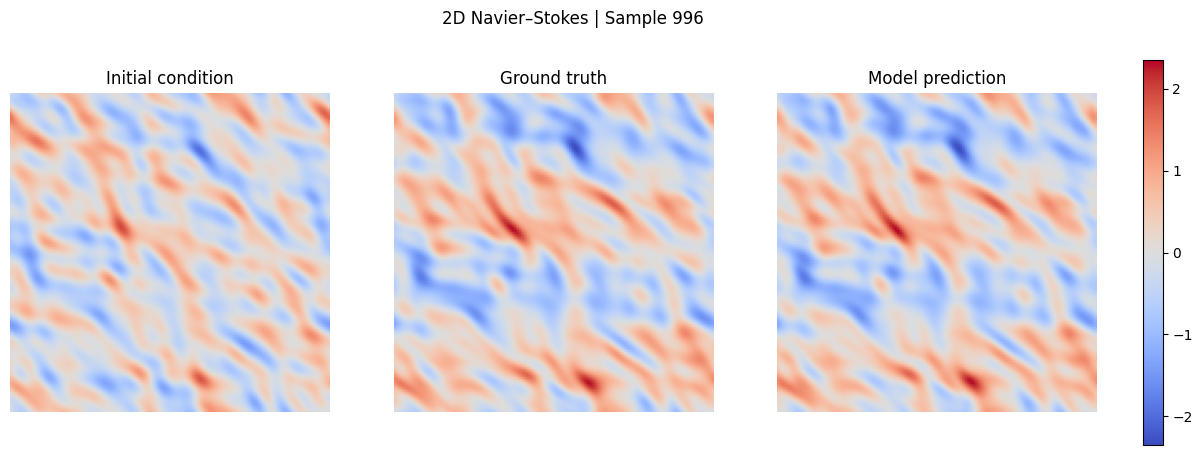

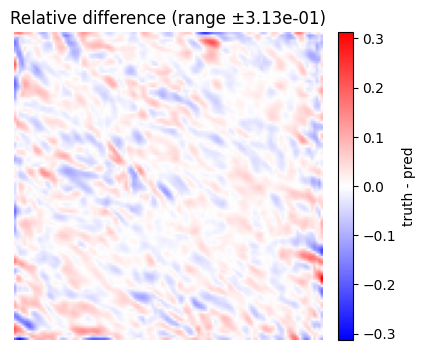

In [10]:
# Plot model prediction

sample_idx = 996
sub = 1

with h5py.File(path, "r") as f:
    omega = f["omega"][:]
omega0 = omega[sample_idx, 0, ::sub, ::sub]
omegaT = omega[sample_idx, 1, ::sub, ::sub]

ω_in = torch.tensor(omega0[None, None, :, :], dtype=torch.float32).to(device)  # (1,1,H,W)
with torch.no_grad():
    ω_pred = model(ω_in)  # -> (1,H,W,1)

ω_pred = ω_pred[0,0].cpu().numpy()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Initial condition", "Ground truth", "Model prediction"]
fields = [omega0, omegaT, ω_pred]

vmin = min(np.min(f) for f in fields)
vmax = max(np.max(f) for f in fields)

for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
plt.suptitle(f"2D Navier–Stokes | Sample {sample_idx}")
#plt.tight_layout()
plt.show()


diff = omegaT - ω_pred
max_abs_diff = np.max(np.abs(diff))

plt.figure(figsize=(5, 4))
plt.imshow(diff, cmap="bwr", origin="lower",
           vmin=-max_abs_diff, vmax=max_abs_diff)
plt.colorbar(fraction=0.046, pad=0.04, label="truth - pred")
plt.title(f"Relative difference (range ±{max_abs_diff:.2e})")
plt.axis("off")
plt.show()